In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/karlyn/Downloads/METABRIC_RNA_Mutation.csv")
print(df.shape)
df.head()

(1904, 693)


/var/folders/d0/kk1nw8tn2t502y3p5gfp5yxc0000gn/T/ipykernel_2130/592801649.py:5: DtypeWarning: Columns (678,688,690,692) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/karlyn/Downloads/METABRIC_RNA_Mutation.csv")


,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0


In [129]:
for col in df.columns:
    print(col)

patient_id
age_at_diagnosis
type_of_breast_surgery
cancer_type
cancer_type_detailed
cellularity
chemotherapy
pam50_+_claudin-low_subtype
cohort
er_status_measured_by_ihc
er_status
neoplasm_histologic_grade
her2_status_measured_by_snp6
her2_status
tumor_other_histologic_subtype
hormone_therapy
inferred_menopausal_state
integrative_cluster
primary_tumor_laterality
lymph_nodes_examined_positive
mutation_count
nottingham_prognostic_index
oncotree_code
overall_survival_months
overall_survival
pr_status
radio_therapy
3-gene_classifier_subtype
tumor_size
tumor_stage
death_from_cancer
brca1
brca2
palb2
pten
tp53
atm
cdh1
chek2
nbn
nf1
stk11
bard1
mlh1
msh2
msh6
pms2
epcam
rad51c
rad51d
rad50
rb1
rbl1
rbl2
ccna1
ccnb1
cdk1
ccne1
cdk2
cdc25a
ccnd1
cdk4
cdk6
ccnd2
cdkn2a
cdkn2b
myc
cdkn1a
cdkn1b
e2f1
e2f2
e2f3
e2f4
e2f5
e2f6
e2f7
e2f8
src
jak1
jak2
stat1
stat2
stat3
stat5a
stat5b
mdm2
tp53bp1
adam10
adam17
aph1a
aph1b
arrdc1
cir1
ctbp1
ctbp2
cul1
dll1
dll3
dll4
dtx1
dtx2
dtx3
dtx4
ep300
fbxw7
hda

In [143]:
# target column
target_col = "pam50_+_claudin-low_subtype"
#check subtypes
print("\nUnique subtype labels:")
print(df[target_col].dropna().unique())

#keep only 4 subtypes
valid_classes = ["LumA", "LumB", "Her2", "Basal"]
df = df.dropna(subset=[target_col]).copy()
df = df[df[target_col].isin(valid_classes)].copy()
print("\nSubtype counts after filtering to 4 classes:")
print(df[target_col].value_counts())

#clinical columns to remove
clinical_cols = [
    'patient_id', 'age_at_diagnosis', 'type_of_breast_surgery',
    'cancer_type', 'cancer_type_detailed', 'cellularity',
    'chemotherapy', 'cohort', 'er_status_measured_by_ihc',
    'er_status', 'neoplasm_histologic_grade',
    'her2_status_measured_by_snp6', 'her2_status',
    'tumor_other_histologic_subtype', 'hormone_therapy',
    'inferred_menopausal_state', 'integrative_cluster',
    'primary_tumor_laterality', 'lymph_nodes_examined_positive',
    'mutation_count', 'nottingham_prognostic_index',
    'oncotree_code', 'overall_survival_months',
    'overall_survival', 'pr_status', 'radio_therapy',
    '3-gene_classifier_subtype', 'tumor_size',
    'tumor_stage', 'death_from_cancer'
]
#mutation columns 
mutation_cols = [col for col in df.columns if col.endswith("_mut")]
print("\nNumber of clinical columns removed:", len(clinical_cols))
print("Number of mutation columns removed:", len(mutation_cols))

#keep only gene columns 
remove_cols = clinical_cols + mutation_cols + [target_col]
remove_cols = [col for col in remove_cols if col in df.columns]
gene_cols = [col for col in df.columns if col not in remove_cols]
print("Initial gene columns:", len(gene_cols))
print("First 20 gene columns:", gene_cols[:20])
#convert gene to numeric 
df[gene_cols] = df[gene_cols].apply(pd.to_numeric, errors="coerce")
#removal all missing gene columns 
all_missing_genes = [col for col in gene_cols if df[col].isnull().all()]
print("All-missing gene columns:", len(all_missing_genes))
print("First 20 all-missing genes:", all_missing_genes[:20])
gene_cols = [col for col in gene_cols if col not in all_missing_genes]
print("Remaining gene columns after removing all-missing:", len(gene_cols))

#creating x and y 
X = df[gene_cols]
y = df[target_col]
#fill missing values
imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(imputer.fit_transform(X), columns=gene_cols)

#remove low variance genes
variances = X.var()
X = X.loc[:, variances > 0.01]
print("Genes after filtering:", X.shape[1])

# standardize data
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# combine into clean dataset
clean_df = pd.concat([X, y.reset_index(drop=True)], axis=1)

print(clean_df.shape)


Unique subtype labels:
['LumA' 'LumB' 'Her2' 'Basal']

Subtype counts after filtering to 4 classes:
pam50_+_claudin-low_subtype
LumA     679
LumB     461
Her2     220
Basal    199
Name: count, dtype: int64

Number of clinical columns removed: 30
Number of mutation columns removed: 173
Initial gene columns: 489
First 20 gene columns: ['brca1', 'brca2', 'palb2', 'pten', 'tp53', 'atm', 'cdh1', 'chek2', 'nbn', 'nf1', 'stk11', 'bard1', 'mlh1', 'msh2', 'msh6', 'pms2', 'epcam', 'rad51c', 'rad51d', 'rad50']
All-missing gene columns: 0
First 20 all-missing genes: []
Remaining gene columns after removing all-missing: 489
Genes after filtering: 489
(1559, 490)


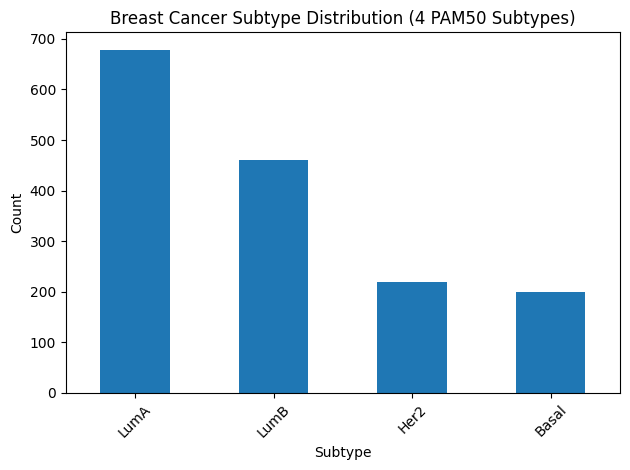

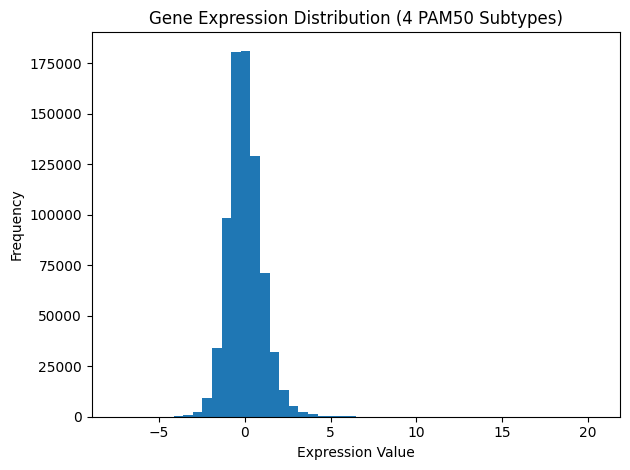

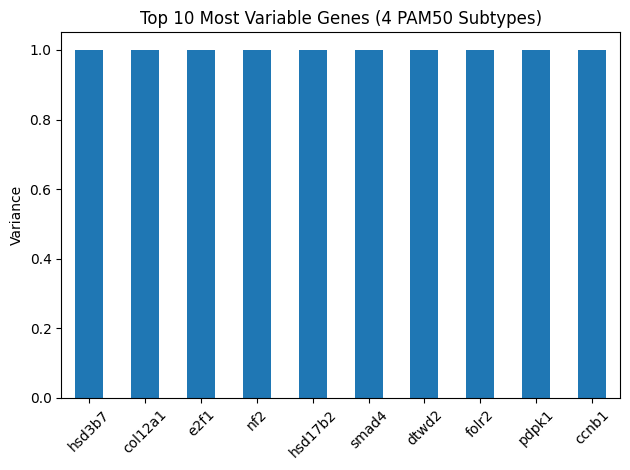

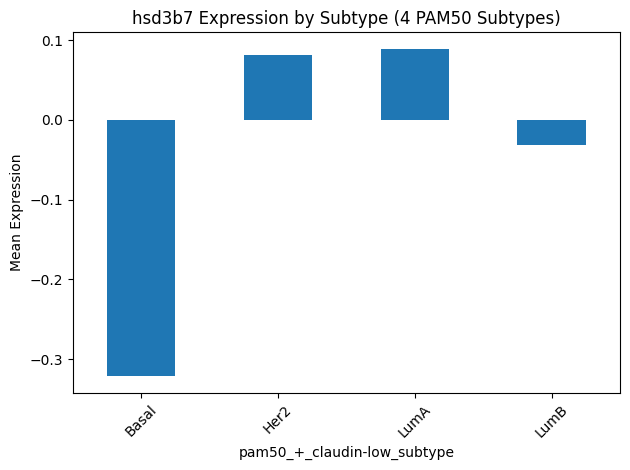

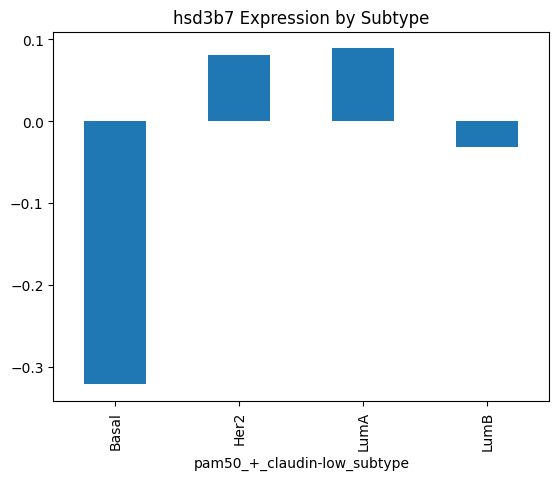

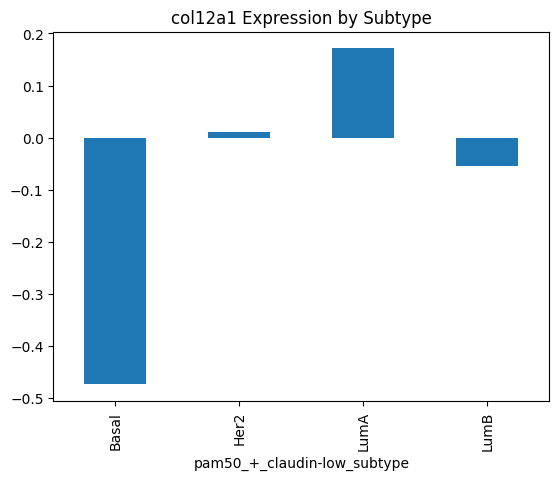

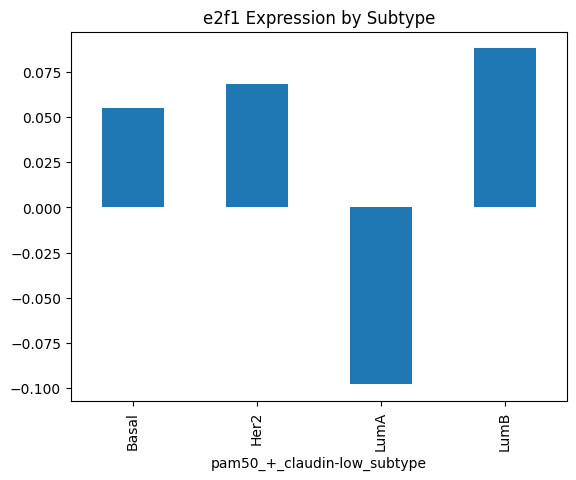

In [141]:
#data exploration
# class distribution
clean_df[target_col].value_counts().plot(kind="bar")
plt.title("Breast Cancer Subtype Distribution (4 PAM50 Subtypes)")
plt.xlabel("Subtype")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# distribution of gene expressions
all_values = X.values.flatten()
plt.hist(all_values, bins=50)
plt.title("Gene Expression Distribution (4 PAM50 Subtypes)")
plt.xlabel("Expression Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# top variable genes across subtypes
top_genes = X.var().sort_values(ascending=False).head(10)
top_genes.plot(kind="bar")
plt.title("Top 10 Most Variable Genes (4 PAM50 Subtypes)")
plt.ylabel("Variance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# gene expression across subtypes
gene = top_genes.index[0]
clean_df.groupby(target_col)[gene].mean().plot(kind="bar")
plt.title(f"{gene} Expression by Subtype (4 PAM50 Subtypes)")
plt.ylabel("Mean Expression")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#hsd3b7 highest variance 
for gene in top_genes.index[:3]:
    clean_df.groupby(target_col)[gene].mean().plot(kind="bar")
    plt.title(f"{gene} Expression by Subtype")
    plt.show()

In [33]:
print("Gene columns used:")
for col in gene_cols:
    print(col)

Gene columns used:
brca1
brca2
palb2
pten
tp53
atm
cdh1
chek2
nbn
nf1
stk11
bard1
mlh1
msh2
msh6
pms2
epcam
rad51c
rad51d
rad50
rb1
rbl1
rbl2
ccna1
ccnb1
cdk1
ccne1
cdk2
cdc25a
ccnd1
cdk4
cdk6
ccnd2
cdkn2a
cdkn2b
myc
cdkn1a
cdkn1b
e2f1
e2f2
e2f3
e2f4
e2f5
e2f6
e2f7
e2f8
src
jak1
jak2
stat1
stat2
stat3
stat5a
stat5b
mdm2
tp53bp1
adam10
adam17
aph1a
aph1b
arrdc1
cir1
ctbp1
ctbp2
cul1
dll1
dll3
dll4
dtx1
dtx2
dtx3
dtx4
ep300
fbxw7
hdac1
hdac2
hes1
hes5
heyl
itch
jag1
jag2
kdm5a
lfng
maml1
maml2
maml3
ncor2
ncstn
notch1
notch2
notch3
nrarp
numb
numbl
psen1
psen2
psenen
rbpj
rbpjl
rfng
snw1
spen
hes2
hes4
hes7
hey1
hey2
acvr1
acvr1b
acvr1c
acvr2a
acvr2b
acvrl1
akt1
akt1s1
akt2
apaf1
arl11
atr
aurka
bad
bcl2
bcl2l1
bmp10
bmp15
bmp2
bmp3
bmp4
bmp5
bmp6
bmp7
bmpr1a
bmpr1b
bmpr2
braf
casp10
casp3
casp6
casp7
casp8
casp9
chek1
csf1
csf1r
cxcl8
cxcr1
cxcr2
dab2
diras3
dlec1
dph1
egfr
eif4e
eif4ebp1
eif5a2
erbb2
erbb3
erbb4
fas
fgf1
fgfr1
folr1
folr2
folr3
foxo1
foxo3
gdf11
gdf2
gsk3b
hif1a
hla-g
